In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


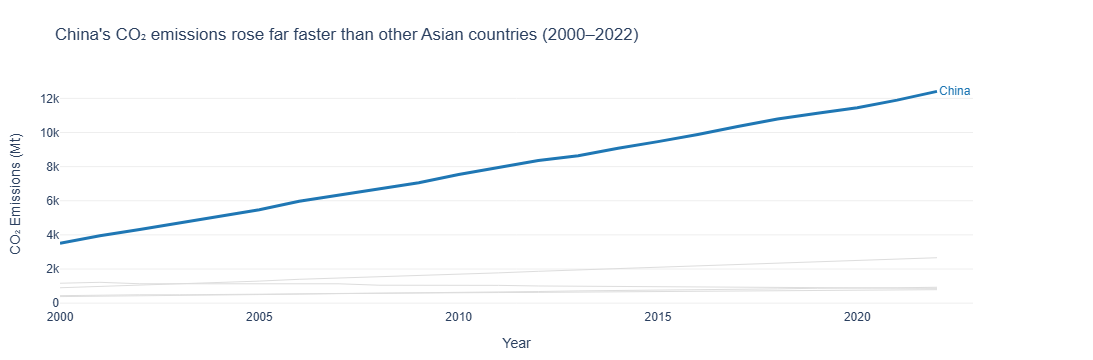

In [4]:
# Task 1 — Multi-series line with highlight
# YOUR CODE HERE
asia = df[df['Region'] == 'Asia'].copy()

highlight_country = "China"

fig = go.Figure()

for country in asia['Country'].unique():
    country_df = asia[asia['Country'] == country].sort_values('Year')

    if country == highlight_country:
        fig.add_trace(
            go.Scatter(
                x=country_df['Year'],
                y=country_df['CO2_Mt'],
                mode='lines',
                name=country,
                line=dict(color='#1f77b4', width=3)
            )
        )
    else:
        fig.add_trace(
            go.Scatter(
                x=country_df['Year'],
                y=country_df['CO2_Mt'],
                mode='lines',
                name=country,
                line=dict(color='#DDDDDD', width=1),
                hoverinfo='skip',
                showlegend=False
            )
        )

# Direct label at end of highlighted line
last_point = (
    asia[asia['Country'] == highlight_country]
    .sort_values('Year')
    .iloc[-1]
)

fig.add_annotation(
    x=last_point['Year'],
    y=last_point['CO2_Mt'],
    text=highlight_country,
    showarrow=False,
    xanchor='left',
    font=dict(size=12, family='Arial', color='#1f77b4')
)

fig.update_layout(
    title="China's CO₂ emissions rose far faster than other Asian countries (2000–2022)",
    font=dict(family="Arial", size=12),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis_title="Year",
    yaxis_title="CO₂ Emissions (Mt)",
    showlegend=False,
    margin=dict(l=60, r=120, t=80, b=50)
)

# Remove clutter
fig.update_xaxes(showgrid=False, showline=False, zeroline=False)
fig.update_yaxes(
    showgrid=True,
    gridcolor='#EEEEEE',
    showline=False,
    zeroline=False
)

fig.show()


Title:China’s CO₂ Emissions Growth Outpaces Regional Neighbors (2000–2022)

Insight: China’s emissions rise far more sharply than other Asian countries, dominating the regional trend. Most other countries show gradual increases or relatively stable patterns. This creates a widening gap between China and the rest of Asia over time. The regional trajectory is therefore heavily skewed by one major emitter. Smaller countries’ trends become less visible due to this imbalance.
    

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


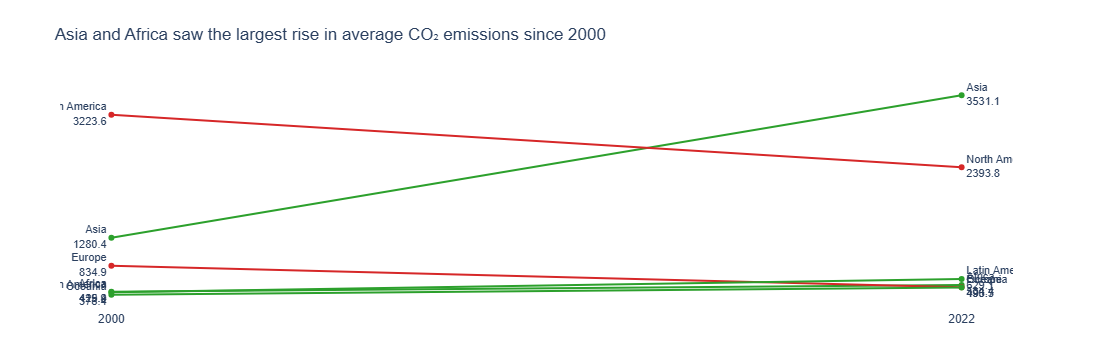

In [5]:
# Task 2 — Slopegraph: regional averages
# YOUR CODE HERE
regional = (
    df.groupby(['Region', 'Year'])['CO2_Mt']
    .mean()
    .reset_index()
)

# Keep only 2000 and 2022
slope = regional[regional['Year'].isin([2000, 2022])].copy()

regions = slope['Region'].unique()

fig = go.Figure()

for region in regions:
    temp = (
        slope[slope['Region'] == region]
        .sort_values('Year')
    )

    y_start = temp[temp['Year'] == 2000]['CO2_Mt'].values[0]
    y_end = temp[temp['Year'] == 2022]['CO2_Mt'].values[0]

    # Color by increase/decrease
    color = '#2ca02c' if y_end > y_start else '#d62728'

    fig.add_trace(
        go.Scatter(
            x=[2000, 2022],
            y=[y_start, y_end],
            mode='lines+markers+text',
            line=dict(color=color, width=2),
            marker=dict(size=6),
            text=[
                f"{region}<br>{y_start:.1f}",
                f"{region}<br>{y_end:.1f}"
            ],
            textposition=['middle left', 'middle right'],
            textfont=dict(family='Arial', size=11),
            showlegend=False,
            hoverinfo='skip'
        )
    )

fig.update_layout(
    title="Asia and Africa saw the largest rise in average CO₂ emissions since 2000",
    font=dict(family="Arial", size=12),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        tickvals=[2000, 2022],
        ticktext=['2000', '2022'],
        showgrid=False,
        zeroline=False
    ),
    yaxis=dict(
        showticklabels=False,
        showgrid=False,
        zeroline=False,
        title=""
    ),
    margin=dict(l=60, r=80, t=80, b=50)
)

fig.show()


Title : Emissions growth is uneven across regions, with Asia rising fastest while some regions stabilize or decline

Insight: Asia shows the largest increase in average emissions from 2000 to 2022. Some regions grow moderately, while others remain stable or decline slightly. The gap between high- and low-emission regions widens over time. This reflects uneven industrial growth and differing policy impacts. Overall, global emissions trends are increasingly driven by a few fast-growing regions.